<a href="https://colab.research.google.com/github/KSaubhagya/Prediction-Module/blob/main/Risk_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

2.Load Data

In [2]:
from google.colab import files
uploaded = files.upload()


Saving dataset final - Prediction Module subset(1).csv to dataset final - Prediction Module subset(1).csv


In [3]:
df = pd.read_csv(list(uploaded.keys())[0])

In [4]:
# Standardize column names
df.columns = df.columns.str.strip()
print(df.columns.tolist())
df.head()

['Name', 'student_id', 'gender', 'program', 'gpa', 'previous_results', 'module_code', 'course_information', 'module_credits', 'ca_weight', 'final_exam_weight', 'ca_marks', 'final_exam_marks', 'total_marks', 'final_grade', 'lecture_attendance', 'attendance_percentage', 'exam_results', 'late_arrivals', 'submission_status', 'login_frequency', 'time_spent_lms', 'resources_accessed', 'forum_chat_activity', 'course_start_date', 'click_count', 'assessment_date', 'assessment_type', 'assessment_score', 'assessment_max_score', 'Learning_Style', 'week_number', 'week_start_date', 'week_end_date', 'assignment_due_date', 'assignment_submission_date', 'sessions_attended', 'total_sessions_held', 'click_timestamp', 'module_id', 'pass_fail_status', 'assignment_max_marks']


,Name,student_id,gender,program,gpa,previous_results,module_code,course_information,module_credits,ca_weight,...,week_start_date,week_end_date,assignment_due_date,assignment_submission_date,sessions_attended,total_sessions_held,click_timestamp,module_id,pass_fail_status,assignment_max_marks
0,Nadeesha Baskaran,ST725,Female,IT,3.11,Good,IN2101,Object Oriented Programming,3.0,40,...,2025-06-30,2025-07-06,2025-07-08,2025-07-07,24,25,2025-05-05 20:40:00,MOD-IN2101,Pass,40
1,Amila Piyarathna,ST383,Male,IT,3.02,Good,IN2901,Software Development Project,4.0,100,...,2025-07-06,2025-07-12,2025-07-12,2025-07-15,15,27,2025-05-25 13:19:00,MOD-IN2901,Pass,100
2,Amila Piyarathna,ST383,Male,IT,3.02,Good,CM2131,Essentials of Mathematical Methods,2.5,30,...,2025-04-27,2025-05-03,2025-05-04,2025-05-08,18,26,2025-05-25 14:00:00,MOD-CM2131,Pass,30
3,Amila Piyarathna,ST383,Male,IT,3.02,Good,IN2101,Object Oriented Programming,3.0,40,...,2025-04-13,2025-04-19,2025-04-20,2025-04-24,12,25,2025-05-25 12:57:00,MOD-IN2101,Pass,40
4,Amila Piyarathna,ST383,Male,IT,3.02,Good,IN2321,Computer Architecture,2.5,30,...,2025-05-11,2025-05-17,2025-05-18,2025-05-22,18,30,2025-05-25 13:11:00,MOD-IN2321,Pass,30


3. Initial Cleaning

In [5]:
# --- Remove duplicates ---
print("Duplicates found:", df.duplicated().sum())
df = df.drop_duplicates()


Duplicates found: 0


In [6]:
# --- Check missing values ---
print(df.isnull().sum())

Name                          0
student_id                    0
gender                        0
program                       0
gpa                           0
previous_results              0
module_code                   0
course_information            0
module_credits                0
ca_weight                     0
final_exam_weight             0
ca_marks                      0
final_exam_marks              0
total_marks                   0
final_grade                   0
lecture_attendance            0
attendance_percentage         0
exam_results                  0
late_arrivals                 0
submission_status             0
login_frequency               0
time_spent_lms                0
resources_accessed            0
forum_chat_activity           0
course_start_date             0
click_count                   0
assessment_date               0
assessment_type               0
assessment_score              0
assessment_max_score          0
Learning_Style                0
week_num

4.Handle Missing Values

In [7]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

In [8]:
print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: ['gpa', 'module_credits', 'ca_weight', 'final_exam_weight', 'ca_marks', 'final_exam_marks', 'total_marks', 'lecture_attendance', 'attendance_percentage', 'exam_results', 'late_arrivals', 'login_frequency', 'time_spent_lms', 'resources_accessed', 'forum_chat_activity', 'click_count', 'assessment_score', 'assessment_max_score', 'sessions_attended', 'total_sessions_held', 'assignment_max_marks']
Categorical columns: ['Name', 'student_id', 'gender', 'program', 'previous_results', 'module_code', 'course_information', 'final_grade', 'submission_status', 'course_start_date', 'assessment_date', 'assessment_type', 'Learning_Style', 'week_number', 'week_start_date', 'week_end_date', 'assignment_due_date', 'assignment_submission_date', 'click_timestamp', 'module_id', 'pass_fail_status']


In [9]:
# Impute numerical missing values with median
num_imputer = SimpleImputer(strategy='median')
df[numerical_cols] = num_imputer.fit_transform(df[numerical_cols])

In [10]:
# Impute categorical missing values with most frequent
cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

Dataset Shape: (6124, 42)

Numerical Columns: 21
Categorical Columns: 21


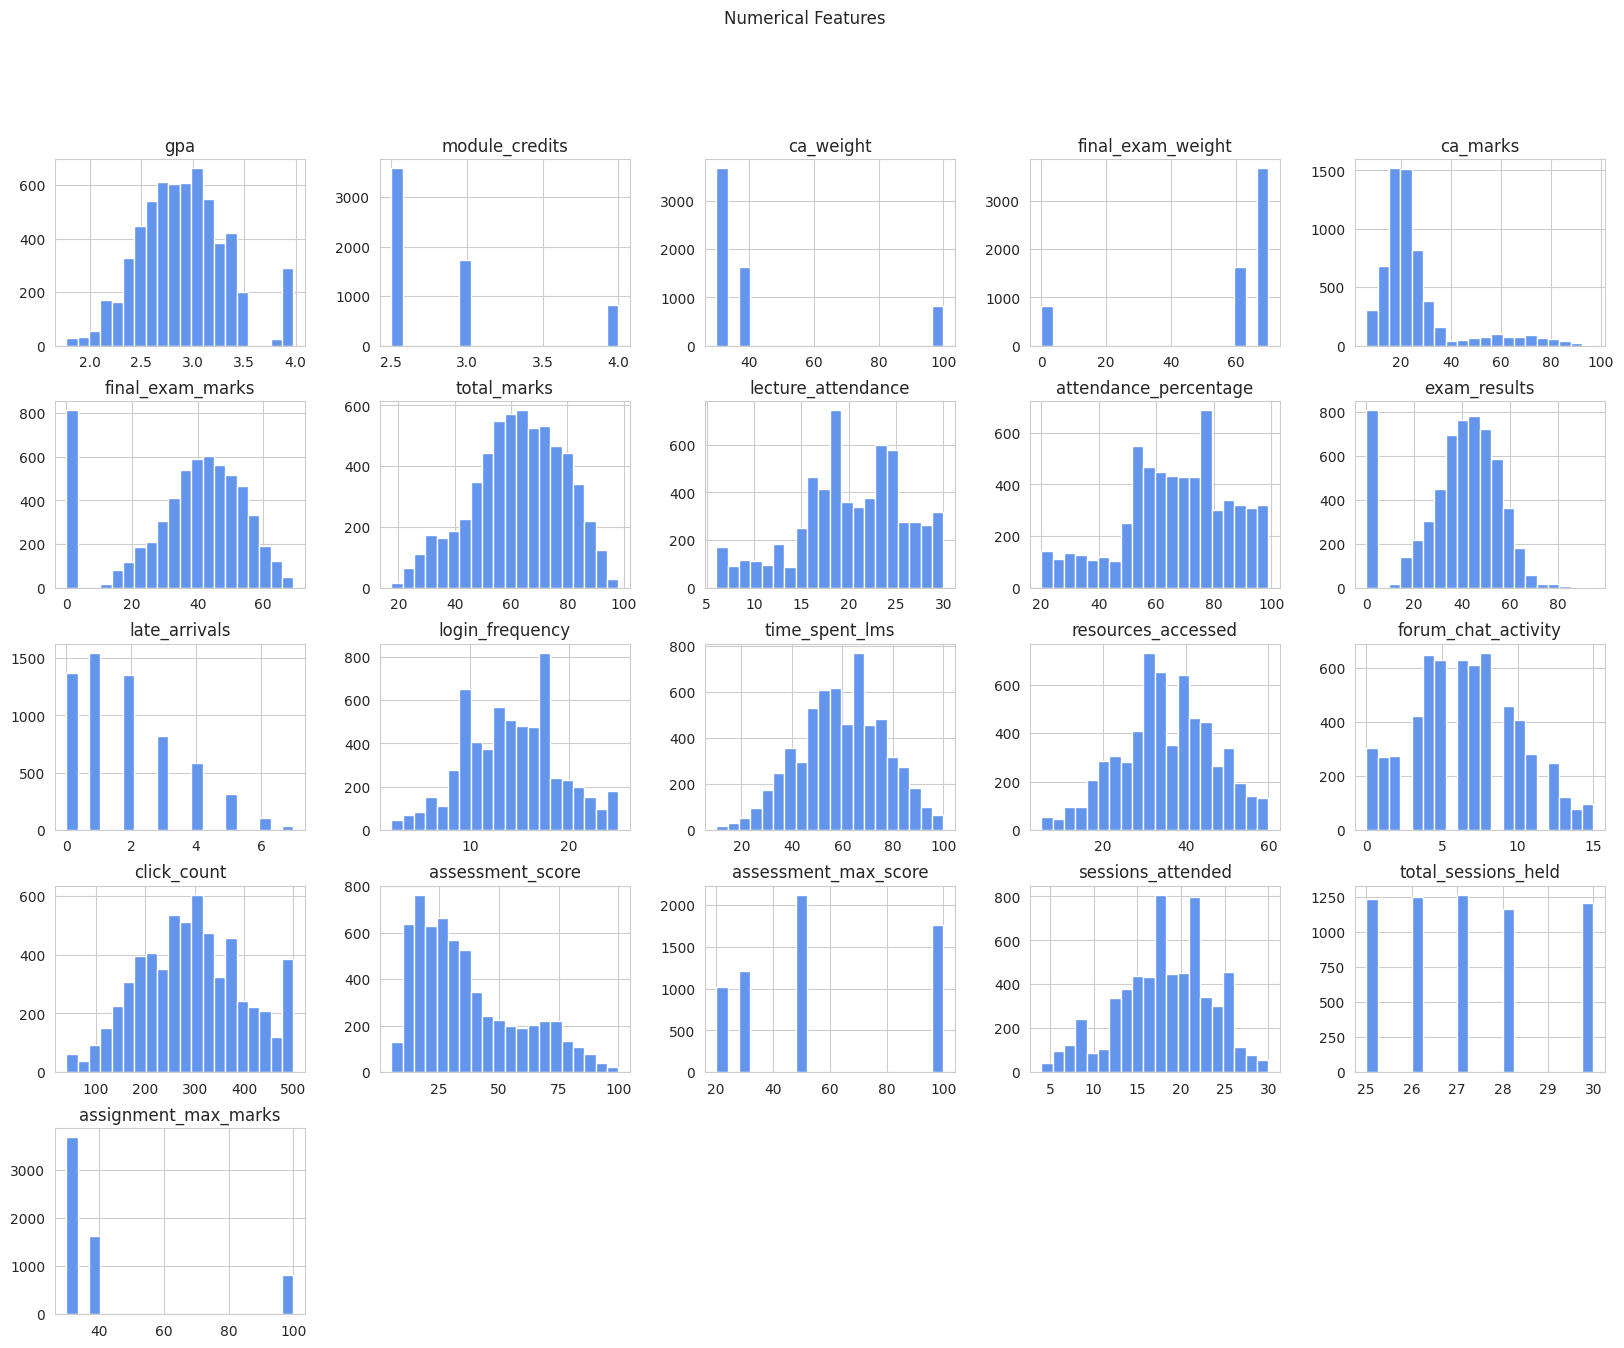

In [23]:
def run_eda(df):
    import matplotlib.pyplot as plt
    import seaborn as sns

    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    cat_cols = df.select_dtypes(include=['object']).columns

    print("Dataset Shape:", df.shape)
    print("\nNumerical Columns:", len(num_cols))
    print("Categorical Columns:", len(cat_cols))

    # Numerical distributions
    df[num_cols].hist(
        bins=20,
        figsize=(20,15),
        color='cornflowerblue'
    )
    plt.suptitle("Numerical Features")
    plt.show()

run_eda(df)

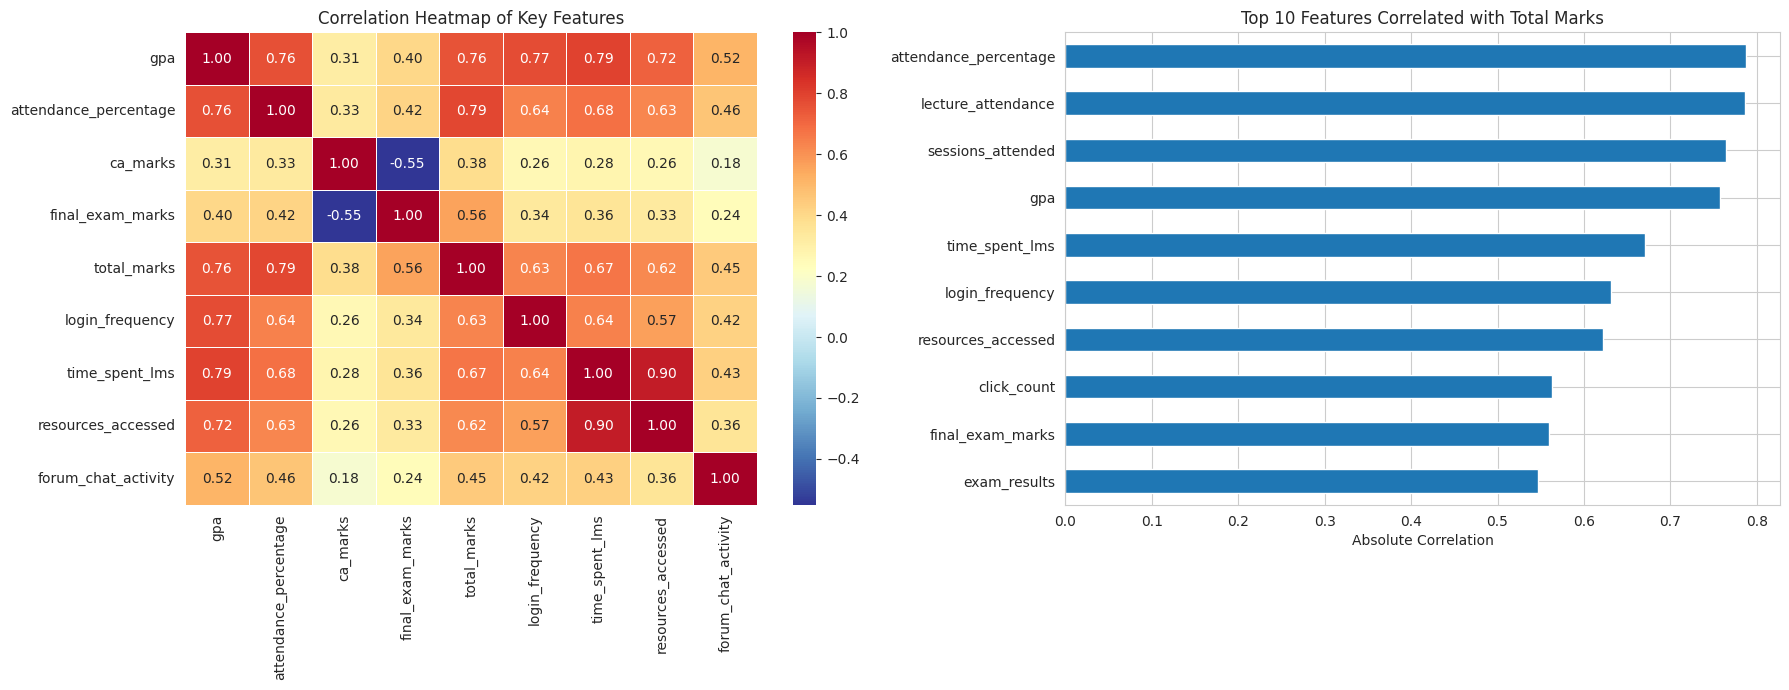

In [28]:
# Key features for heatmap
heatmap_features = [
    'gpa',
    'attendance_percentage',
    'ca_marks',
    'final_exam_marks',
    'total_marks',
    'login_frequency',
    'time_spent_lms',
    'resources_accessed',
    'forum_chat_activity'
]

# Create figure with 2 plots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap
sns.heatmap(
    df[heatmap_features].corr(),
    annot=True,
    cmap='RdYlBu_r',
    fmt='.2f',
    linewidths=0.5,
    ax=axes[0]
)

axes[0].set_title('Correlation Heatmap of Key Features')


# Top Correlations with Total Marks
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

corr_target = (
    df[num_cols]
    .corr()['total_marks']
    .drop('total_marks')
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

corr_target.sort_values().plot(
    kind='barh',
    ax=axes[1]
)

axes[1].set_title('Top 10 Features Correlated with Total Marks')
axes[1].set_xlabel('Absolute Correlation')

plt.tight_layout()
plt.show()

5. CATEGORICAL ENCODING (One-Hot)

In [29]:
# Identify date columns to exclude from one-hot encoding
date_like_cols = ['course_start_date', 'assessment_date']
ohe_cols = [c for c in categorical_cols if c not in date_like_cols]

In [30]:
print("Columns to one-hot encode:", ohe_cols)

Columns to one-hot encode: ['Name', 'student_id', 'gender', 'program', 'previous_results', 'module_code', 'course_information', 'final_grade', 'submission_status', 'assessment_type', 'Learning_Style', 'week_number', 'week_start_date', 'week_end_date', 'assignment_due_date', 'assignment_submission_date', 'click_timestamp', 'module_id', 'pass_fail_status']


In [31]:
# One-hot encode
df_encoded = pd.get_dummies(df, columns=ohe_cols, drop_first=False)


6. TEMPORAL FEATURES

In [32]:
df_encoded['course_start_date'] = pd.to_datetime(df_encoded['course_start_date'], errors='coerce')
df_encoded['assessment_date'] = pd.to_datetime(df_encoded['assessment_date'], errors='coerce')

In [33]:
# Week number relative to course start
df_encoded['week_number'] = (
    (df_encoded['assessment_date'] - df_encoded['course_start_date']).dt.days // 7
) + 1

In [34]:
# Days since course start
df_encoded['days_since_start'] = (
    df_encoded['assessment_date'] - df_encoded['course_start_date']
).dt.days

7. FEATURE ENGINEERING (multi-source)

In [35]:
# Engagement score (LMS clicks + time + forum activity)
df_encoded['engagement_score'] = (
    df_encoded['click_count'].fillna(0) +
    df_encoded['time_spent_lms'].fillna(0) +
    df_encoded['forum_chat_activity'].fillna(0)
)

In [36]:
# Assessment performance ratio
df_encoded['assessment_ratio'] = (
    df_encoded['assessment_score'] / df_encoded['assessment_max_score']
)

In [37]:
# Weighted CA contribution
df_encoded['weighted_score'] = df_encoded['assessment_ratio'] * df_encoded['ca_weight']

In [38]:
# Low attendance flag
df_encoded['low_attendance_flag'] = (df_encoded['attendance_percentage'] < 75).astype(int)

8. SCALE NUMERICAL FEATURES

In [39]:
# Recompute numerical columns after feature engineering
final_numerical_cols = df_encoded.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [40]:
# Exclude IDs from scaling
exclude_from_scaling = ['student_id', 'week_number']
scale_cols = [c for c in final_numerical_cols if c not in exclude_from_scaling]

In [41]:
scaler = StandardScaler()
df_encoded[scale_cols] = scaler.fit_transform(df_encoded[scale_cols])

9. FINAL CHECK

In [42]:
print(df_encoded.shape)
df_encoded.head()

(6124, 8739)


,gpa,module_credits,ca_weight,final_exam_weight,ca_marks,final_exam_marks,total_marks,lecture_attendance,attendance_percentage,exam_results,...,module_id_MOD-IS2240,module_id_MOD-IS2901,pass_fail_status_Fail,pass_fail_status_Pass,week_number,days_since_start,engagement_score,assessment_ratio,weighted_score,low_attendance_flag
0,0.500158,0.318116,-0.084567,0.084567,0.197593,0.378915,0.615265,1.411534,1.555238,1.990131,...,False,False,False,True,6,-0.245939,0.779902,0.565133,0.109386,-1.273411
1,0.285854,2.303993,2.511376,-2.511376,2.583137,-2.047697,0.299880,-0.535445,-0.597368,-2.017016,...,False,False,False,True,8,0.893775,0.039775,0.274409,2.536483,0.785292
2,0.285854,-0.674822,-0.517225,0.517225,-0.524921,0.295045,-0.194842,0.172547,0.109537,0.251896,...,False,False,False,True,8,0.893775,0.039775,0.274409,-0.407273,0.785292
3,0.285854,0.318116,-0.084567,0.084567,-0.325607,-0.392681,-0.757588,-0.712443,-0.756821,-0.414157,...,False,False,False,True,8,0.893775,0.039775,0.274409,0.013263,0.785292
4,0.285854,-0.674822,-0.517225,0.517225,-0.686864,-0.135482,-0.831797,-0.535445,-0.485752,-0.165064,...,False,False,False,True,8,0.893775,0.039775,0.274409,-0.407273,0.785292
